In [51]:
# install libraries

%pip install duckdb

In [52]:
# =====================================================
# DUCKDB SQL ANALYTICS
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print("Dataset Shape:")
print(master.shape)

print("\nFirst 5 Rows:")
print(master.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape:
(25059, 35)

First 5 Rows:
   hadm_id  subject_id   admittime   dischtime  los_days admission_type  \
0   200000      100000  2022-01-06  2022-01-23        17         URGENT   
1   200001      100000  2019-11-08  2019-11-20        12       ELECTIVE   
2   200002      100000  2023-09-04  2023-09-23        19       ELECTIVE   
3   200003      100000  2023-06-14  2023-06-28        14         URGENT   
4   200004      100001  2019-08-15  2019-08-23         8    OBSERVATION   

  discharge_location  anchor_age gender      race  ...  CHF  CKD  COPD  \
0            EXPIRED          69      M     ASIAN  ...    0    0     1   
1               HOME          69      M     ASIAN  ...    0    0     1   
2              REHAB          69      M     ASIAN  ...    0    0     1   
3            EXPIRED          69      M     ASIAN  ...    0    0     1   
4       

In [53]:
# create DUCKDB connection
# =====================================

con = duckdb.connect()
# Register dataframe so SQL can use it
con.register("master", master)

DATA OVERVIEW
----------------------------------------


,admissions,patients,avg_los,avg_resource
0,25059,10000,10.002793,20.365338



Length of Stay by Admission Type


,admission_type,admissions,avg_los,median_los
0,OBSERVATION,6236,10.067832,10.0
1,URGENT,6210,10.059581,10.0
2,ELECTIVE,6332,9.993051,10.0
3,EMERGENCY,6281,9.891896,10.0


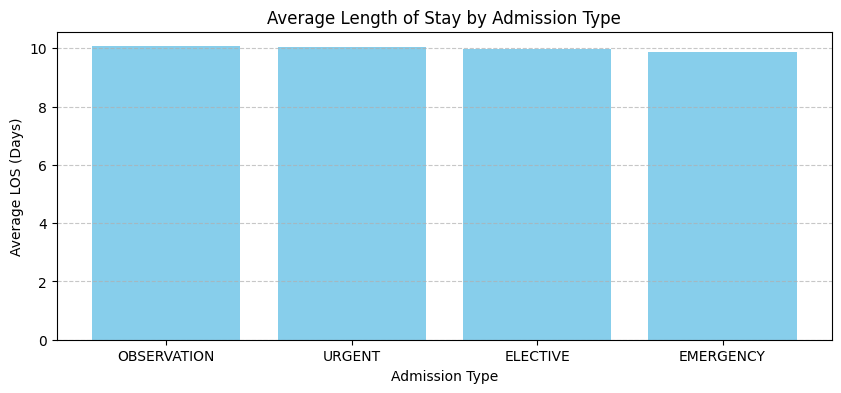

In [54]:
# =====================================
# 1. DATA OVERVIEW & QUESTION 1: HOSPITAL EFFICIENCY
# =====================================
print("DATA OVERVIEW")
print("-" * 40)

overview_query = """
SELECT
    COUNT(*) AS admissions,
    COUNT(DISTINCT subject_id) AS patients,
    AVG(los_days) AS avg_los,
    AVG(resource_score) AS avg_resource
FROM master
"""
overview = con.execute(overview_query).df()
display(overview)

# Length of Stay by Admission Type
los_query = """
SELECT
    admission_type,
    COUNT(*) AS admissions,
    AVG(los_days) AS avg_los,
    MEDIAN(los_days) AS median_los
FROM master
GROUP BY admission_type
ORDER BY avg_los DESC
"""
los_df = con.execute(los_query).df()
print("\nLength of Stay by Admission Type")
display(los_df)

# Plot Average Length of Stay
plt.figure(figsize=(10, 4))
plt.bar(los_df["admission_type"], los_df["avg_los"], color='skyblue')
plt.title("Average Length of Stay by Admission Type")
plt.ylabel("Average LOS (Days)")
plt.xlabel("Admission Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [55]:
import matplotlib.pyplot as plt

# =====================================
# RESOURCE UTILIZATION & BOTTLENECK ANALYSIS
# =====================================

# Resource utilization by admission type
resource_query = """
SELECT
    admission_type,
    AVG(resource_score) AS avg_resource
FROM master
GROUP BY admission_type
ORDER BY avg_resource DESC
"""
resource_df = con.execute(resource_query).df()
print("Resource Utilization:")
display(resource_df)

# 30-Day Readmission Rates
readmit_query = """
SELECT
    admission_type,
    AVG(readmit_30d) AS readmission_rate
FROM master
GROUP BY admission_type
ORDER BY readmission_rate DESC
"""
readmit_df = con.execute(readmit_query).df()

# Average ICU Length of Stay
icu_query = """
SELECT
    admission_type,
    AVG(icu_los) AS avg_icu_los
FROM master
GROUP BY admission_type
ORDER BY avg_icu_los DESC
"""
icu_df = con.execute(icu_query).df()

# Bottleneck Analysis (Combined)
bottleneck_query = """
SELECT
    admission_type,
    AVG(los_days) AS avg_los,
    AVG(resource_score) AS avg_resource,
    AVG(readmit_30d) AS readmission_rate,
    AVG(icu_los) AS avg_icu_los
FROM master
GROUP BY admission_type
ORDER BY avg_los DESC
"""
bottleneck_df = con.execute(bottleneck_query).df()
print("\nPossible Bottlenecks:")
display(bottleneck_df)

Resource Utilization:


,admission_type,avg_resource
0,OBSERVATION,20.428801
1,EMERGENCY,20.427002
2,URGENT,20.331240
3,ELECTIVE,20.275111



Possible Bottlenecks:


,admission_type,avg_los,avg_resource,readmission_rate,avg_icu_los
0,OBSERVATION,10.067832,20.428801,0.144965,4.009267
1,URGENT,10.059581,20.331240,0.153623,3.986424
2,ELECTIVE,9.993051,20.275111,0.144188,3.985458
3,EMERGENCY,9.891896,20.427002,0.151727,3.985814


QUESTION 2: Which Patient Characteristics Are Linked To Poor Outcomes
----------------------------------------
Age Group Analysis:


,age_group,mortality_rate,readmission_rate
0,61-80,0.086541,0.149742
1,41-60,0.085113,0.147787
2,80+,0.082770,0.145692
3,18-40,0.080635,0.150033


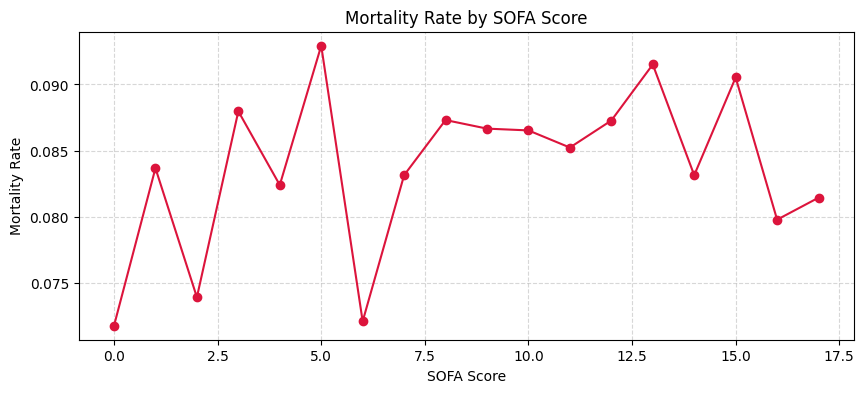

Charlson Index Analysis:


,charlson_score,mortality_rate
0,1.0,0.089167
1,2.0,0.080779
2,3.0,0.082456
3,4.0,0.085358


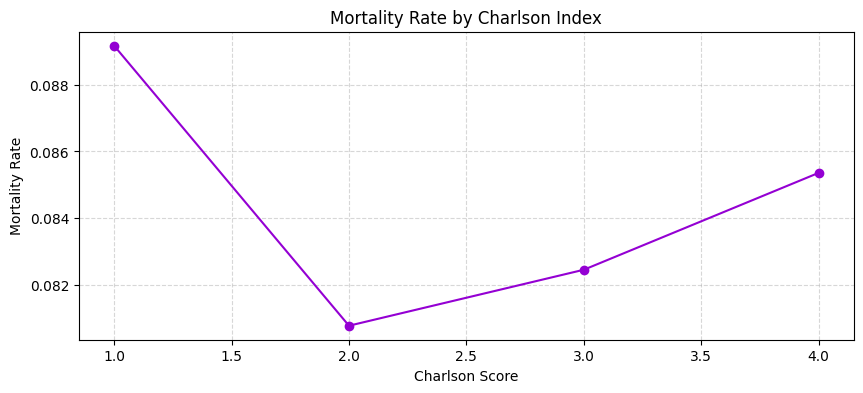


High Risk Groups Analysis:


,age_group,mortality_rate,sepsis_rate,ventilation_rate
0,61-80,0.086541,0.122310,0.080782
1,41-60,0.085113,0.124110,0.085113
2,80+,0.082770,0.115697,0.082544
3,18-40,0.080635,0.118440,0.076669


In [56]:
# =====================================
# QUESTION 2: PATIENT CHARACTERISTICS & POOR OUTCOMES
# =====================================
print("QUESTION 2: Which Patient Characteristics Are Linked To Poor Outcomes")
print("-" * 40)

# Age Group Analysis
age_query = """
SELECT
    age_group,
    AVG(mortality_90d) AS mortality_rate,
    AVG(readmit_30d) AS readmission_rate
FROM master
GROUP BY age_group
ORDER BY mortality_rate DESC
"""
age_df = con.execute(age_query).df()
print("Age Group Analysis:")
display(age_df)

# SOFA Score Analysis
sofa_query = """
SELECT
    sofa,
    AVG(mortality_90d) AS mortality_rate
FROM master
GROUP BY sofa
ORDER BY sofa
"""
sofa_df = con.execute(sofa_query).df()

# Plot Mortality by SOFA Score
plt.figure(figsize=(10, 4))
plt.plot(sofa_df["sofa"], sofa_df["mortality_rate"], marker="o", color="crimson")
plt.title("Mortality Rate by SOFA Score")
plt.xlabel("SOFA Score")
plt.ylabel("Mortality Rate")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Charlson Index Analysis:")
charlson_query = """
SELECT
    ROUND(charlson_index) AS charlson_score,
    AVG(mortality_90d) AS mortality_rate
FROM master
GROUP BY charlson_score
ORDER BY charlson_score
"""
charlson_df = con.execute(charlson_query).df()
display(charlson_df)

# Plot Mortality by Charlson Index
plt.figure(figsize=(10, 4))
plt.plot(
    charlson_df["charlson_score"],
    charlson_df["mortality_rate"],
    marker="o",
    color="darkviolet"
)
plt.title("Mortality Rate by Charlson Index")
plt.xlabel("Charlson Score")
plt.ylabel("Mortality Rate")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# High Risk Groups analysis for risk_df
risk_query = """
SELECT
    age_group,
    AVG(mortality_90d) AS mortality_rate,
    AVG(sepsis) AS sepsis_rate,
    AVG(ventilation) AS ventilation_rate
FROM master
GROUP BY age_group
ORDER BY mortality_rate DESC
"""
risk_df = con.execute(risk_query).df()
print("\nHigh Risk Groups Analysis:")
display(risk_df)

In [57]:
# correlation analysis
# =====================================

print("\nCorrelation Analysis")
print("-" * 40)

numeric_data = master.select_dtypes(
    include=np.number
)

corr_matrix = numeric_data.corr()

mortality_corr = corr_matrix[
    "mortality_90d"
].sort_values(
    ascending=False
)

print("\nVariables Most Related to Mortality")
print(mortality_corr.head(15).to_string())


Correlation Analysis
----------------------------------------

Variables Most Related to Mortality
mortality_90d      1.000000
los_days           0.166417
long_stay          0.146039
mortality          0.029316
icu_los            0.015797
sofa               0.007531
sepsis             0.005899
subject_id         0.005458
hadm_id            0.005453
Diabetes           0.005406
resource_score     0.005344
num_labs           0.004988
num_medications    0.004521
anchor_age         0.004520
COPD               0.003657


In [58]:
# INVESTIGATE MORTALITY RELATIONSHIP
# =====================================================
# Checking 'mortality' and 'mortality_90d' columns overlapping
cross_tab = pd.crosstab(master['mortality'], master['mortality_90d'], margins=True)
print("Cross-tabulation of mortality vs mortality_90d:")
display(cross_tab)


Cross-tabulation of mortality vs mortality_90d:


mortality_90d,0,1,All
mortality,,,
0,20734,1828,22562
1,2227,270,2497
All,22961,2098,25059


### Recommendation for cell organization
To prevent Colab outputs from being truncated and to make your pipeline easier to debug, consider splitting the long cell `KnBCFTENvcxL` into distinct sections (e.g., separating Question 1 visualizations from Question 2's clinical risk analysis).

In [59]:
# exporting results
# =====================================

los_df.to_csv(
    f"{DATA_PATH}/sql_los_analysis.csv",
    index=False
)

resource_df.to_csv(
    f"{DATA_PATH}/sql_resource_analysis.csv",
    index=False
)

bottleneck_df.to_csv(
    f"{DATA_PATH}/sql_bottlenecks.csv",
    index=False
)

risk_df.to_csv(
    f"{DATA_PATH}/sql_risk_analysis.csv",
    index=False
)

print("\nFiles Saved Successfully")

print("""
Created Files:

sql_los_analysis.csv
sql_resource_analysis.csv
sql_bottlenecks.csv
sql_risk_analysis.csv
""")


Files Saved Successfully

Created Files:

sql_los_analysis.csv
sql_resource_analysis.csv
sql_bottlenecks.csv
sql_risk_analysis.csv

